### **문제 A: 영상 전처리 및 분석 (25분)**

**문제 설명:**
주어진 이미지 파일( `image.png` )을 읽어와서 아래의 요구사항을 충족하는 파이썬 코드를 작성하세요.

1. **이미지 로드 및 채널 분리:**
    - `image.png` 파일을 NumPy 배열로 읽어와, B, G, R 채널로 분리하여 각 채널의 평균 픽셀 값을 계산하고 출력하세요.
    - **힌트:** OpenCV의 `cv2.imread()`와 NumPy의 배열 슬라이싱을 활용하세요.
2. **특정 색상 영역 추출:**
    - BGR 이미지를 HSV(Hue, Saturation, Value) 색상 공간으로 변환하세요.
    - HSV 공간에서 **빨간색** 영역을 나타내는 범위를 정의하고, 해당 범위에 해당하는 픽셀만 흰색(255, 255, 255)으로, 나머지는 검은색(0, 0, 0)으로 채운 이진 마스크 이미지를 생성하세요.
    - **힌트:** 빨간색은 HSV 공간에서 두 개의 범위(0~10과 170~180)에 걸쳐 나타날 수 있습니다. `cv2.inRange()` 함수를 활용하여 마스크를 생성하세요.
3. **결과 이미지 저장:**
    - 생성된 이진 마스크 이미지를 `red_mask.png`라는 파일명으로 저장하세요.

In [1]:
# 문제 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_array = cv2.imread('image_A.jpg')
img = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

print(img.mean(axis=(0,1)))

[180.22365952  99.05121613 105.41025162]


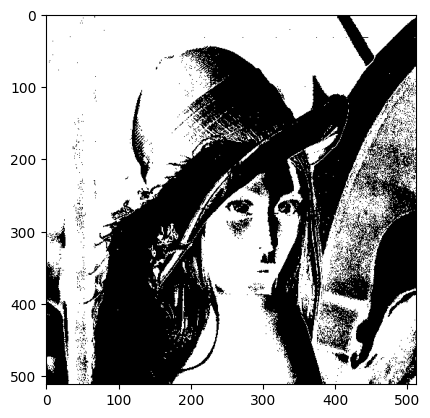

In [4]:
# 문제 2
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# 첫 번째 범위: 0-10
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])

# 두 번째 범위: 170-180
lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([180, 255, 255])

# 4. 각 범위에 대한 이진 마스크 생성
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

# 5. 두 마스크 병합 (논리합 연산)
red_mask = cv2.add(mask1, mask2)

plt.imshow(red_mask, cmap='gray')
plt.show()

In [3]:
# 문제 3
cv2.imwrite('red_mask.png', red_mask)

True

### **문제 B: 객체 인식 및 시각화 (35분)**

**문제 설명:**
주어진 이미지(`image_B.jpg`)에 대해 사전 학습된 YOLO 모델을 사용하여 특정 객체를 탐지하고, 그 결과를 시각화하는 코드를 작성하세요.

1. **모델 로드 및 객체 탐지:**
    - `yolov8n.pt` 모델을 로드하세요.
    - 로드한 모델을 사용하여 `image_B.jpg` 파일 내의 모든 객체를 탐지하고, 그 결과를 `results` 변수에 저장하세요.
    - **힌트:** `ultralytics` 라이브러리의 `YOLO` 클래스를 사용하세요.
2. **특정 객체 정보 추출:**
    - 탐지된 객체 중에서 **'car'** 클래스에 해당하는 객체만 필터링하세요.
    - 탐지된 'car' 객체의 바운딩 박스 좌표, 신뢰도(confidence score), 클래스 이름을 각각 추출하여 출력하세요.
    - **힌트:** `results[0].boxes` 객체에서 클래스 정보(`cls`)와 바운딩 박스 정보(`xyxy`), 신뢰도(`conf`)를 가져올 수 있습니다.
3. **결과 시각화:**
    - 탐지된 **모든** 객체에 대해 바운딩 박스와 클래스 이름을 원본 이미지 위에 그려 시각화하세요.
    - 시각화된 이미지를 `detection_result.jpg`라는 파일명으로 저장하세요.
    - **힌트:** `results[0].plot()` 메서드를 활용하면 편리하게 시각화할 수 있습니다.

image 1/1 /workspaces/study-and-commit/image_B.jpg: 416x640 6 persons, 26 cars, 4 motorcycles, 2 buss, 1 truck, 202.9ms
Speed: 57.6ms preprocess, 202.9ms inference, 26.9ms postprocess per image at shape (1, 3, 416, 640)


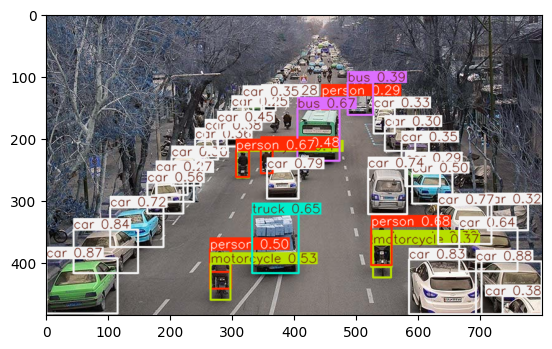

In [6]:
# 문제 1
from ultralytics import YOLO

# 'yolov8n.pt' (YOLOv8 nano 모델) 로드
model = YOLO('yolov8n.pt')

results = model('image_B.jpg')
plotted_img = results[0].plot()

plt.imshow(plotted_img)
plt.show()

In [10]:
# 문제 2
car_class_id = 2

# 탐지된 객체 정보가 담긴 boxes 객체 가져오기
boxes = results[0].boxes

print("--- 'car' 객체 정보 ---")
# boxes 객체 순회하며 각 객체 정보 추출
for box in boxes:
    # 클래스 ID와 신뢰도 점수 가져오기
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    # 클래스 ID가 'car'에 해당하는 경우 필터링
    if class_id == car_class_id:
        # 바운딩 박스 좌표 (x1, y1, x2, y2) 가져오기
        xyxy = box.xyxy[0].tolist()
        
        # 클래스 이름 가져오기
        class_name = model.names[class_id]
        
        # 추출된 정보 출력
        print(f"클래스: {class_name}")
        print(f"좌표(xyxy): [{xyxy[0]:.2f}, {xyxy[1]:.2f}, {xyxy[2]:.2f}, {xyxy[3]:.2f}]")
        print(f"신뢰도: {confidence:.2f}")
        print("-" * 20)

--- 'car' 객체 정보 ---
클래스: car
좌표(xyxy): [693.65, 398.60, 799.69, 483.87]
신뢰도: 0.88
--------------------
클래스: car
좌표(xyxy): [0.05, 393.35, 115.23, 482.21]
신뢰도: 0.87
--------------------
클래스: car
좌표(xyxy): [44.97, 347.67, 148.11, 417.49]
신뢰도: 0.84
--------------------
클래스: car
좌표(xyxy): [585.31, 395.88, 702.74, 483.93]
신뢰도: 0.83
--------------------
클래스: car
좌표(xyxy): [356.42, 249.21, 407.43, 297.49]
신뢰도: 0.79
--------------------
클래스: car
좌표(xyxy): [632.67, 307.76, 718.99, 370.82]
신뢰도: 0.77
--------------------
클래스: car
좌표(xyxy): [519.68, 248.84, 582.12, 322.77]
신뢰도: 0.74
--------------------
클래스: car
좌표(xyxy): [103.00, 311.66, 189.53, 375.15]
신뢰도: 0.72
--------------------
클래스: car
좌표(xyxy): [666.41, 344.08, 760.12, 414.74]
신뢰도: 0.64
--------------------
클래스: car
좌표(xyxy): [163.06, 271.73, 221.61, 321.51]
신뢰도: 0.56
--------------------
클래스: car
좌표(xyxy): [590.81, 256.98, 655.91, 305.04]
신뢰도: 0.50
--------------------
클래스: car
좌표(xyxy): [276.56, 175.00, 326.80, 213.65]
신뢰도: 0.45
--------

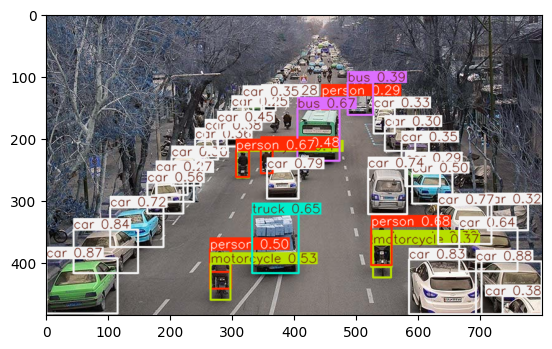

True

In [11]:
# 문제 3
plotted_img = results[0].plot()

plt.imshow(plotted_img)
plt.show()

cv2.imwrite('detection_result.jpg', plotted_img)


image 1/1 /workspaces/study-and-commit/image_B.jpg: 416x640 6 persons, 26 cars, 4 motorcycles, 2 buss, 1 truck, 105.6ms
Speed: 3.6ms preprocess, 105.6ms inference, 4.0ms postprocess per image at shape (1, 3, 416, 640)
--- 'car' 객체 시각화 시작 ---
Car detected: car 0.88, BBox: (693, 398, 799, 483)
Car detected: car 0.87, BBox: (0, 393, 115, 482)
Car detected: car 0.84, BBox: (44, 347, 148, 417)
Car detected: car 0.83, BBox: (585, 395, 702, 483)
Car detected: car 0.79, BBox: (356, 249, 407, 297)
Car detected: car 0.77, BBox: (632, 307, 718, 370)
Car detected: car 0.74, BBox: (519, 248, 582, 322)
Car detected: car 0.72, BBox: (103, 311, 189, 375)
Car detected: car 0.64, BBox: (666, 344, 760, 414)
Car detected: car 0.56, BBox: (163, 271, 221, 321)
Car detected: car 0.50, BBox: (590, 256, 655, 305)
Car detected: car 0.45, BBox: (276, 174, 326, 213)
Car detected: car 0.38, BBox: (256, 187, 291, 219)
Car detected: car 0.38, BBox: (736, 454, 799, 483)
Car detected: car 0.36, BBox: (240, 201, 277, 

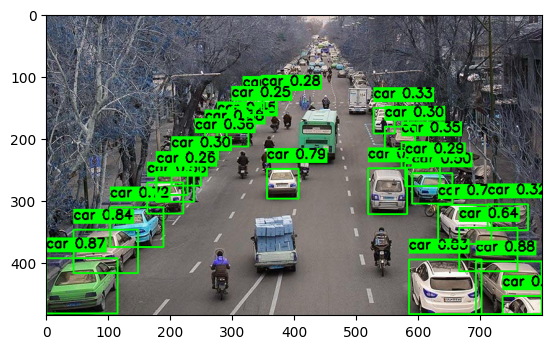

In [12]:
# 추가 - car만 찾아내기

from ultralytics import YOLO
import cv2
import numpy as np # 혹시 모를 배열 처리 필요 시 대비

# 1. 모델 불러오기
model = YOLO('yolov8n.pt')

# 2. 이미지로 객체 탐지 수행
image_path = 'image_B.jpg' # 'car' 객체가 포함된 이미지 경로 (실제 파일 경로로 변경하세요)
results = model(image_path)

# 3. 원본 이미지 불러오기 (OpenCV는 BGR 형식을 사용)
original_img = cv2.imread(image_path)

# 4. 'car' 클래스 ID 정의 (COCO 데이터셋 기준)
car_class_id = 2

# 5. 시각화 설정
# 바운딩 박스와 텍스트 색상 (BGR)
color = (0, 255, 0)      # 초록색
thickness = 2            # 바운딩 박스 선 두께
font = cv2.FONT_HERSHEY_SIMPLEX # 폰트 종류
font_scale = 0.7         # 폰트 크기
font_thickness = 2       # 폰트 두께

# 6. 'car' 객체 필터링 및 시각화
print("--- 'car' 객체 시각화 시작 ---")
if results[0].boxes: # 탐지된 객체가 있는지 확인
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        
        # 'car' 클래스인 경우에만 처리
        if class_id == car_class_id:
            # 바운딩 박스 좌표 (x1, y1, x2, y2)
            # 좌표는 float이므로 정수형으로 변환
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            
            # 신뢰도 점수
            confidence = float(box.conf[0])
            
            # 클래스 이름
            class_name = model.names[class_id]
            
            # 바운딩 박스 그리기
            cv2.rectangle(original_img, (x1, y1), (x2, y2), color, thickness)
            
            # 텍스트 생성 (클래스 이름과 신뢰도)
            label = f"{class_name} {confidence:.2f}"
            
            # 텍스트 배경을 위한 텍스트 크기 계산
            (text_width, text_height), baseline = cv2.getTextSize(label, font, font_scale, font_thickness)
            
            # 텍스트 배경 박스 그리기 (옵션)
            # 텍스트가 바운딩 박스 외부에 그려지도록 Y좌표 조정
            text_y_offset = y1 - 10 if y1 - 10 > text_height else y1 + text_height + 10 # 텍스트 위치 조정
            cv2.rectangle(original_img, (x1, text_y_offset - text_height - baseline), 
                          (x1 + text_width, text_y_offset), color, -1) # -1은 채우기
            
            # 텍스트 그리기
            cv2.putText(original_img, label, (x1, text_y_offset - baseline), 
                        font, font_scale, (0, 0, 0), font_thickness) # 텍스트 색상은 검은색으로
            
            print(f"Car detected: {label}, BBox: ({x1}, {y1}, {x2}, {y2})")

else:
    print("이미지에서 탐지된 객체가 없습니다.")


# (선택 사항) 저장된 이미지 확인
plt.imshow(original_img)
plt.show()
